# Caso Práctico: Predicciones de Series Temporales empleando ML

En este caso práctico veremos cómo aplicar diferentes algoritmos de ML para realizar pronósticos de series temporales.

Para ello, emplearemos 2 conjuntos de datos distintos: Air Passengers y ADS.

El conjunto de datos Air Passengers es un dataset ampliamente empleado a la hora de aprender análisis de series temporales. Por otra parte, el conjunto de datos ADS contiene el número de anuncios vistos por hora en un determinados juegos para móviles.


Recordemos que abordar el pronóstico de series temporales aplicando ML implica predecir valores continuos basados en puntos de datos históricos ordenados por tiempo. Esto puede representarse formalmente con la siguiente expresión:


$y_{t+1} = f(y_t, y_{t-1}, ..., y_{t-k}, X_t) + \epsilon$

Donde:
- $y_t, y_{t-1}, ..., y_{t-k}$ son valores rezagados de la variable objetivo $y$, que representan observaciones históricas hasta el momento $t$.
- $X_t$ representa características o predictores adicionales que pueden influir en la variable objetivo en el momento $t$.
- $f()$ es una función que captura la relación entre los valores rezagados y los predictores para predecir el valor futuro de $y$.
- $\epsilon$ es el término de error, que representa la diferencia entre el valor previsto y el valor real en el momento $t+1$.

Esta ecuación representa una forma generalizada que puede aplicarse a varios algoritmos de ML para el pronóstico de series temporales. Dependiendo del modelo empleado, la función $f()$ que captura la relación entre las variables será diferente. Por ejemplo, en caso de emplear la regresión lineal, la función $f()$ corresponderá con algún tipo de función lineal. En caso de emplear Random Forest o XGBoost, la función $f()$ estará basada en árboles de decición.

Este cuaderno está organizado de la siguiente forma:

1. Importación de librerías de python necesarias
    1. Funciones creadas para llevar a cabo el caso práctico
1. Conjunto de datos Air Passengers
    1. Lectura de datos
    1. Etapa de preprocesado y preparación de datos
    1. Entrenamiento y evaluación de modelos
1. Conjunto de datos ADS
    1. Lectura de datos
    1. Etapa de preprocesado y preparación de datos
    1. Entrenamiento y evaluación de modelos

In [1]:
!pip install xgboost

   ---------------------------------------- 0.0/150.0 MB ? eta -:--:--
   -- ------------------------------------- 8.7/150.0 MB 53.8 MB/s eta 0:00:03
   ----- ---------------------------------- 20.4/150.0 MB 56.2 MB/s eta 0:00:03
   -------- ------------------------------- 31.2/150.0 MB 55.0 MB/s eta 0:00:03
   ----------- ---------------------------- 43.0/150.0 MB 55.9 MB/s eta 0:00:02
   -------------- ------------------------- 56.1/150.0 MB 57.7 MB/s eta 0:00:02
   ------------------ --------------------- 68.7/150.0 MB 58.4 MB/s eta 0:00:02
   --------------------- ------------------ 81.5/150.0 MB 59.1 MB/s eta 0:00:02
   ------------------------- -------------- 94.6/150.0 MB 59.8 MB/s eta 0:00:01
   --------------------------- ----------- 105.6/150.0 MB 59.2 MB/s eta 0:00:01
   ------------------------------ -------- 117.2/150.0 MB 58.5 MB/s eta 0:00:01
   ---------------------------------- ---- 130.8/150.0 MB 58.9 MB/s eta 0:00:01
   ------------------------------------- - 144.2/1

# Importación de librerías

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
from matplotlib import pyplot
import statsmodels.api as sm
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

## Funciones

In [3]:
# Differentiation
def difference(series, interval=1):
    differenced_series = series.diff(periods=interval)
    return differenced_series

# Inverse Differentiation
def inverse_difference(diff_series, initial_value):
    inverse_diff = [initial_value]
    for i in range(1, diff_series.shape[0]):
        inverse_diff.append(inverse_diff[i-1]+diff_series[i])    
    return inverse_diff

# Create time-delay embedding
def create_time_delay_embedding(data, horizon=6, final_lag=24, column="y", column_index=None):
    df = pd.DataFrame()
    df["y"] = data[column].copy()
    for i in range(horizon, final_lag+1):
        df["lag_{}".format(i)] = data[column].shift(i)
    if column_index is None:
        df.index = data.index
    else:
        df.index = data[column_index]
    return df

# Train-Test split
def timeseries_train_test_split(X, y, test_size):
    test_index = int(len(X)*(1-test_size))
    
    X_train = X.iloc[:test_index]
    y_train = y.iloc[:test_index]
    X_test = X.iloc[test_index:]
    y_test = y.iloc[test_index:]
    
    return X_train, X_test, y_train, y_test

# Forecast bias
def forecast_bias_aggregate(actuals, predictions):
    return 100*(np.nansum(predictions)-np.nansum(actuals))/np.nansum(actuals)

# Evaluation metrics
def compute_metrics(y_true, y_pred):
    bias = forecast_bias_aggregate(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    
    print(f"Forecast Bias: {bias:.2f}%")
    print(f"Mean Square Error: {mse:.4f}")
    print(f"Mean Absolute Error: {mae:.4f}")
    print(f"Mean Absolute Percentage Error: {mape:.2f}")

    return {"bias":bias,
            "mse":mse,
            "mae":mae
            }

# Mean abosulte percentage error (MAPE)
def mean_absolute_percentage_error(y_true, y_pred): 
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# Plot model results
def plotModelResults(model, X_train, X_test, y_test, plot_intervals=False, plot_anomalies=False):
    prediction = model.predict(X_test)
    
    plt.figure(figsize=(15, 7))
    plt.plot(prediction, "g", label="prediction", linewidth=2.0)
    plt.plot(y_test.values, label="actual", linewidth=2.0)

    compute_metrics(y_test, prediction)
    error = mean_absolute_percentage_error(prediction, y_test)
    plt.title("Mean absolute percentage error {0:.2f}%".format(error))
    plt.legend(loc="best")
    plt.tight_layout()
    plt.grid(True)
    plt.show()
    
# Plot feature importance
def plotCoefficients(model, X_train):
    if not isinstance(model, LinearRegression):
        coefs = pd.DataFrame(model.feature_importances_, X_train.columns)
    else:
        coefs = pd.DataFrame(model.coef_, X_train.columns)
    coefs.columns = ["coef"]
    coefs["abs"] = coefs.coef.apply(np.abs)
    coefs = coefs.sort_values(by="abs", ascending=False).drop(["abs"], axis=1)
    
    plt.figure(figsize=(15, 7))
    coefs.coef.plot(kind='bar')
    plt.grid(True, axis='y')
    plt.hlines(y=0, xmin=0, xmax=len(coefs), linestyles='dashed')
    plt.show()


# Air Passengers

En esta sección abordaremos el pronóstico de series temporales para el conjunto de datos Air Passengers.

## Lectura de datos

In [4]:
csv_path = 'AirPassengers.csv'
df = pd.read_csv(csv_path)
df.head()

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


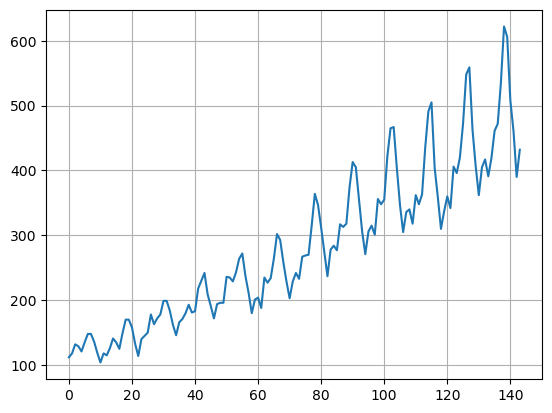

In [5]:
df['#Passengers'].plot().grid()

## Etapa de preprocesado

Como podemos ver en la gráfica de arriba. Los datos presentan un tendencia positiva junto con una estacionalidad bastante clara. Además, el valor de las observaciones es de varios centenares. Podemos examinar la distribución de los datos para observar si presentan una distribución normal.

<Axes: >

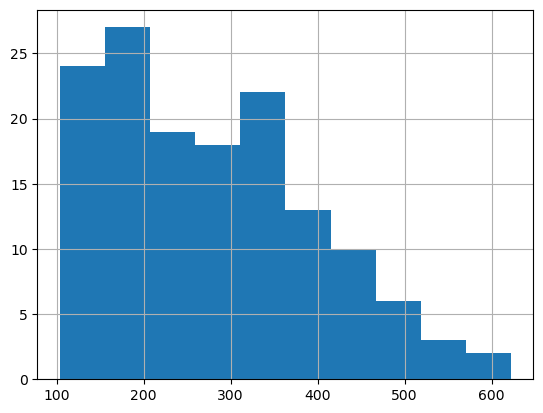

In [6]:
df['#Passengers'].hist()

Empleando el histogramos observamos que la distribución de las observaciones está lejos de ser normal. Por tanto, la etapa de preprocesado va a requerir al menos 2 procesos. Algún tipo de transformación para conseguir que la distribución se parezca más a una campana de Gauss y una etapa de escalado para acotar el valor de las observaciones a números más pequeños.

Para ello, emplearemos la transformación logarítmica *Logaritmo Natural* y el escalado *Min-Max*

In [7]:
minmax_scaler = MinMaxScaler()
starndard_scaler = StandardScaler()

df['Fecha'] = df['Month']
df['NumerPasajeros'] = df['#Passengers']

df['LogNatural-NumeroPasajeros'] = np.log(df['NumerPasajeros'].values)
df['Min-Max-NumeroPasajeros'] = minmax_scaler.fit_transform(df['LogNatural-NumeroPasajeros'].values.reshape(-1,1))

<Axes: >

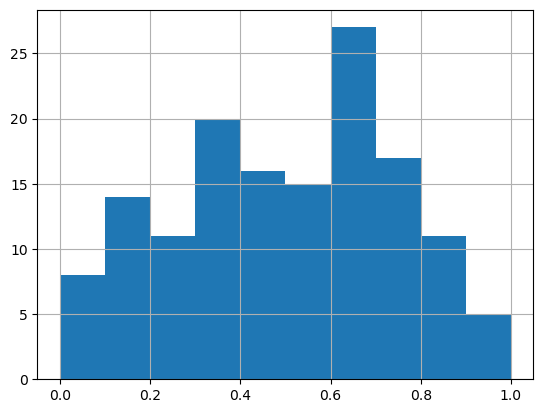

In [8]:
df['Min-Max-NumeroPasajeros'].hist()

### Preparación de datos

Una vez tenemos los datos con propiedades más adecuadas para alimentar nuestros modelos de ML, necesitamos prepararlos para que los modelos puedan procesarlos. Esta etapa consiste en crear el conocido time-delay embedding que consiste en convertir la serie temporal en datos tabulares.

En esta fase necesitamos seleccionar el *Lag*, que se conoce como el número de observaciones pasadas empleadas para realizar la predicción, y también el número de observaciones en adelante, es decir, el horizonte del pronóstico.

Para poder seleccionar estos dos parámetros es necesario aversiguar la relación entre las observaciones. Para ello, empleamos la herramienta de la autocorrelación parcial. Esta técnica permite conocer la relación entre una observación y cada una de las observaciones pasadas.

In [9]:
acorr = sm.tsa.acf(df['Min-Max-NumeroPasajeros'], nlags = 80)

fig = make_subplots(rows=1, cols=1,
                    shared_xaxes=False,
                    shared_yaxes=True,
                    vertical_spacing=0.08,
                    )

fig.add_trace(go.Scatter(y=acorr, name="Autocorrelación", mode="markers+lines"),
              row=1, col=1)

fig.add_hline(y=0.5, row=1, col=1, line_dash="dash")
fig.add_hline(y=-0.5, row=1, col=1, line_dash="dash")

fig.update_layout(height=500, width=500,
                  title_text="Autocorrelación"
                  )

fig['layout']['xaxis1']['title']='Retardo (Intervalos)'
fig.show()

In [10]:
pacorr = sm.tsa.pacf(df['Min-Max-NumeroPasajeros'], nlags=20)

fig = make_subplots(rows=1, cols=1,
                    shared_xaxes=False,
                    shared_yaxes=True,
                    vertical_spacing=0.08,
                    )

fig.add_trace(go.Scatter(y=pacorr,
                         name="Autocorrelación",
                         mode="markers+lines"),
              row=1, col=1)

fig.add_hline(y=0.5,
              row=1,
              col=1,
              line_dash="dash")

fig.add_hline(y=-0.5,
              row=1,
              col=1,
              line_dash="dash")

fig.update_layout(height=500,
                  width=500,
                  title_text="Autocorrelación Parcial"
                  )

fig['layout']['xaxis1']['title']='Retardo (Intervalos)'
fig.show()

Después de representar la autocorrelación parcial observamos que las observaciones presentan una alta relación cuando se tiene un lag de 12.

Para observar la importancia de seleccionar bien los parámetros de horizonte y lag vamos a mostrar los resultados obtenidos de escoger valores para estos parámetros sin ningún tipo criterio. Para ello, configuramos estos valores a $horizonte=2$ y $lag=4$.

In [11]:
horizon=2
final_lag=4


data = create_time_delay_embedding(df,
                                   horizon=horizon,
                                   final_lag=final_lag,
                                   column="Min-Max-NumeroPasajeros",
                                   column_index="Month")

y = data.dropna().y
X = data.dropna().drop(['y'], axis=1)

X_train, X_test, y_train, y_test = timeseries_train_test_split(X, y, test_size=0.3)

El resultado de la preparación es el siguiente:
- X_train: Tabla que contiene los datos de entrada para el modelo. Corresponde con las observaciones pasadas a partir de las cuales se ha de obtener el pronóstico. Esta tabla se emplea en la fase de entrenamiento del modelo.
- y_train: Vector que contiene los valores reales que el modelo debe ser capaz de predecir. Este vector se emplea en la fase de entrenamiento del modelo.
- X_test: Tabla que contiene los datos de entrada para el modelo. Esta tabla se emplea en la fase de evaluación para confirmar que el modelo ha sido capaz de capturar los patrones y puede generalizar. 
- y_test: Vector que contiene los valores reales. Este vector se emplea para evaluar las predicciones del modelo durante la fase de evaluación

In [12]:
X_train.head()

,lag_2,lag_3,lag_4
Month,,,
1949-05,0.133299,0.070612,0.041435
1949-06,0.120445,0.133299,0.070612
1949-07,0.084649,0.120445,0.133299
1949-08,0.145863,0.084649,0.120445
1949-09,0.197267,0.145863,0.084649


In [13]:
y_train[0:5]

Month
1949-05    0.084649
1949-06    0.145863
1949-07    0.197267
1949-08    0.197267
1949-09    0.149990
Name: y, dtype: float64

## Forecasting

Una vez tenemos los datos preparados para alimentar los modelos de ML podemos comenzar con la fase de entrenamiento y evaluación. 

Los modelos que vamos utilizar son:
- Regresión Lineal
- Random Forest
- XGBoost

Para evaluar las prestaciones de los modelos vamos a calcular las siguientes métricas:
- Sesgo del pronóstico: Indica si los pronósticos tienden a sobrestimar o subestimar sistemáticamente los valores reales. Se calcula como la diferencia promedio entre los pronósticos y los valores reales.
- Error cuadrático medio: Indica la discrepancia entre los valores pronosticados y los valores observados al cuadrado. Se calcula sumando los cuadrados de las diferencias entre los pronósticos y los valores reales, y luego dividiendo por el número de observaciones.
- Error absoluto medio:  las diferencias absolutas entre los pronósticos y los valores reales. Se calcula sumando las diferencias absolutas entre los pronósticos y los valores reales y luego dividiendo por el número de observaciones.
- Error absoluto porcentual medio: Indica la precisión relativa del pronóstico. Se calcula como el promedio de los errores absolutos relativos, es decir, la diferencia absoluta entre el pronóstico y el valor real dividida por el valor real, expresado como un porcentaje.


La siguiente celda de código realiza las siguientes acciones:
- Ajuste de los modelos con el subconjunto de entrenamiento (*X_train* e *y_train*).
- Realización de predicciones con el subconjunto de test.
- Representación de predicciones para el subconjunto de test y los valores reales.
- Cálculo de métricas de evaluación.

Observamos que las predicciones son bastante malas y esto es debido a que no hemos seleccionado adecuadamente los valores de *horizonte* y *lag*.

---------------------------------------
Linear Regression results
Forecast Bias: -2.83%
Mean Square Error: 0.0099
Mean Absolute Error: 0.0862
Mean Absolute Percentage Error: 11.01


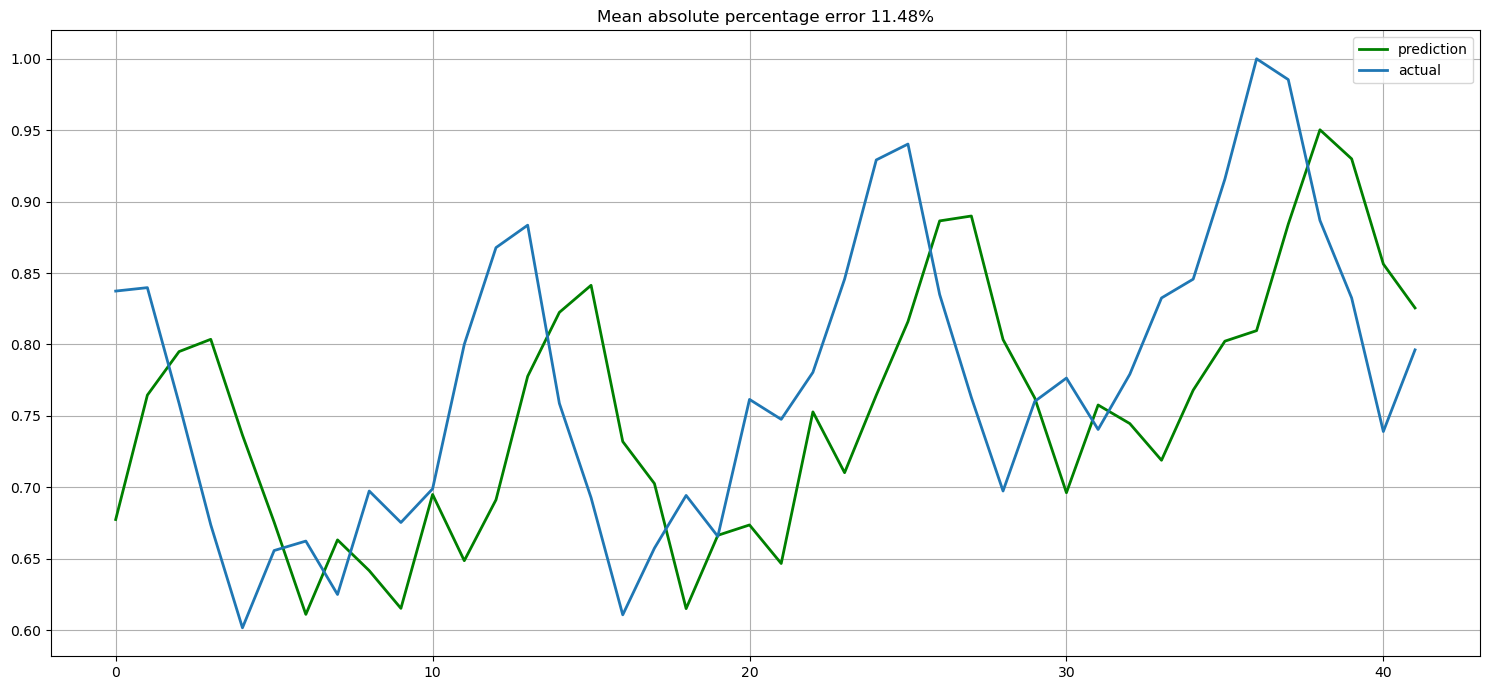

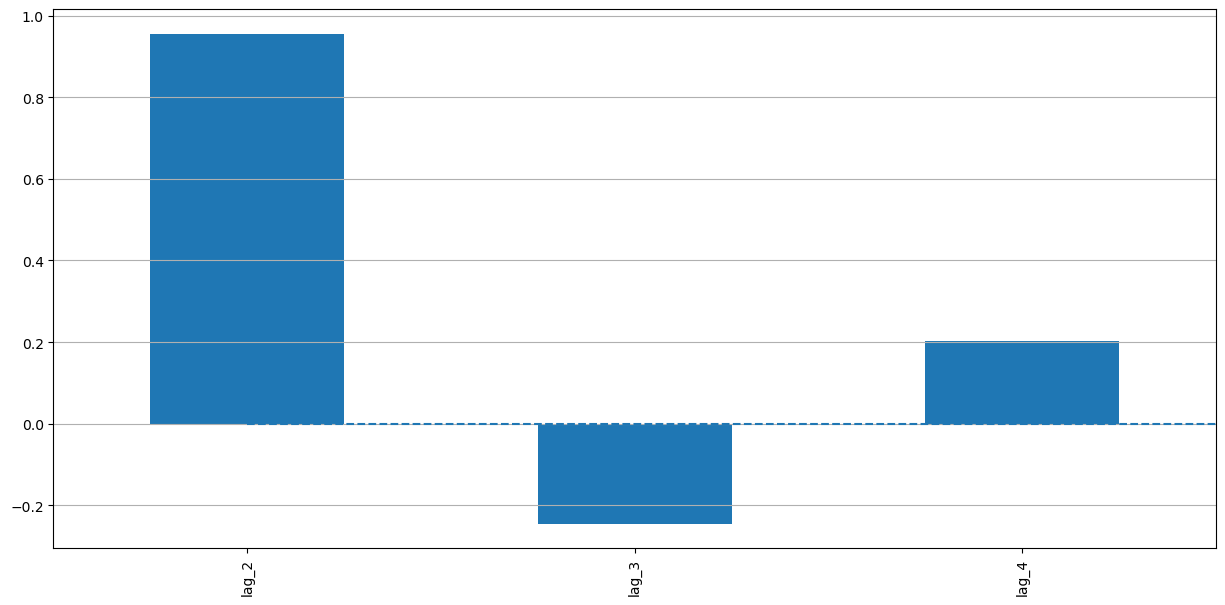



---------------------------------------
Random Forest results
Forecast Bias: -19.85%
Mean Square Error: 0.0344
Mean Absolute Error: 0.1553
Mean Absolute Percentage Error: 18.77


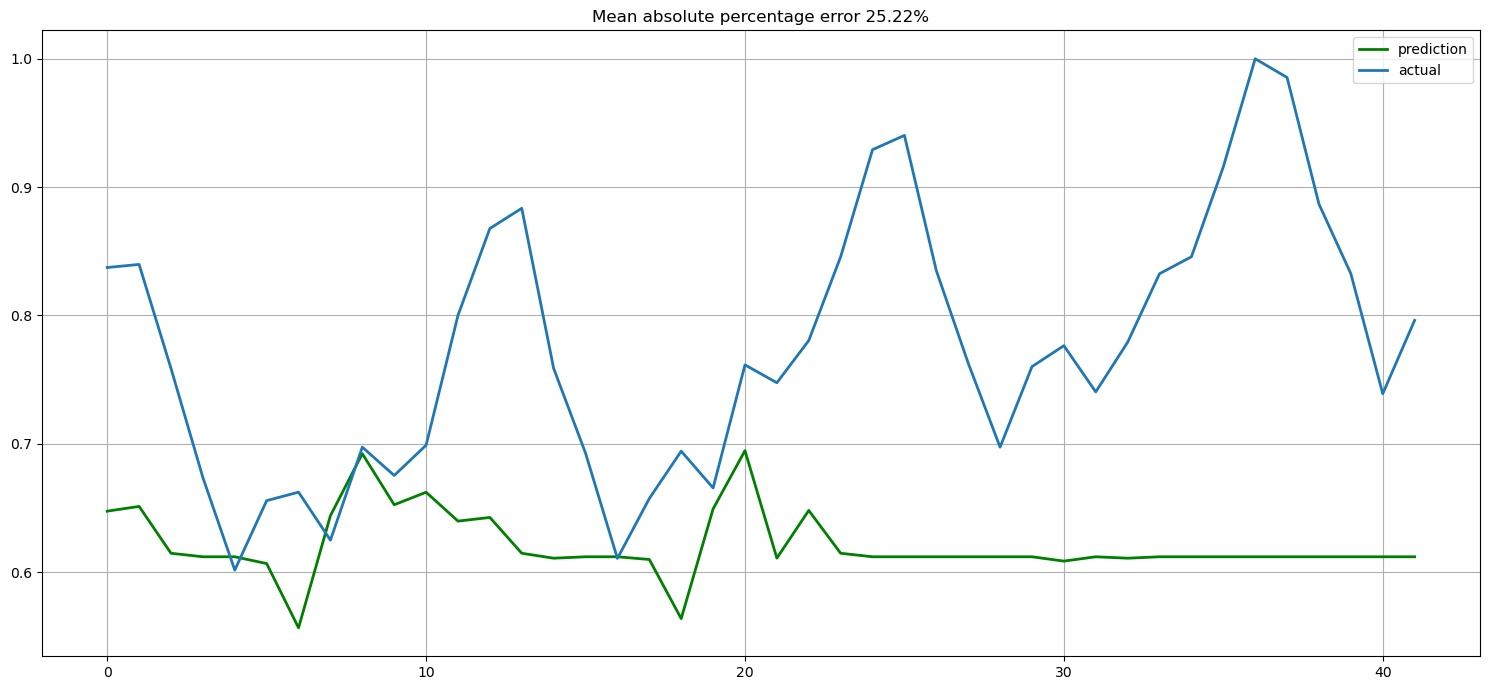

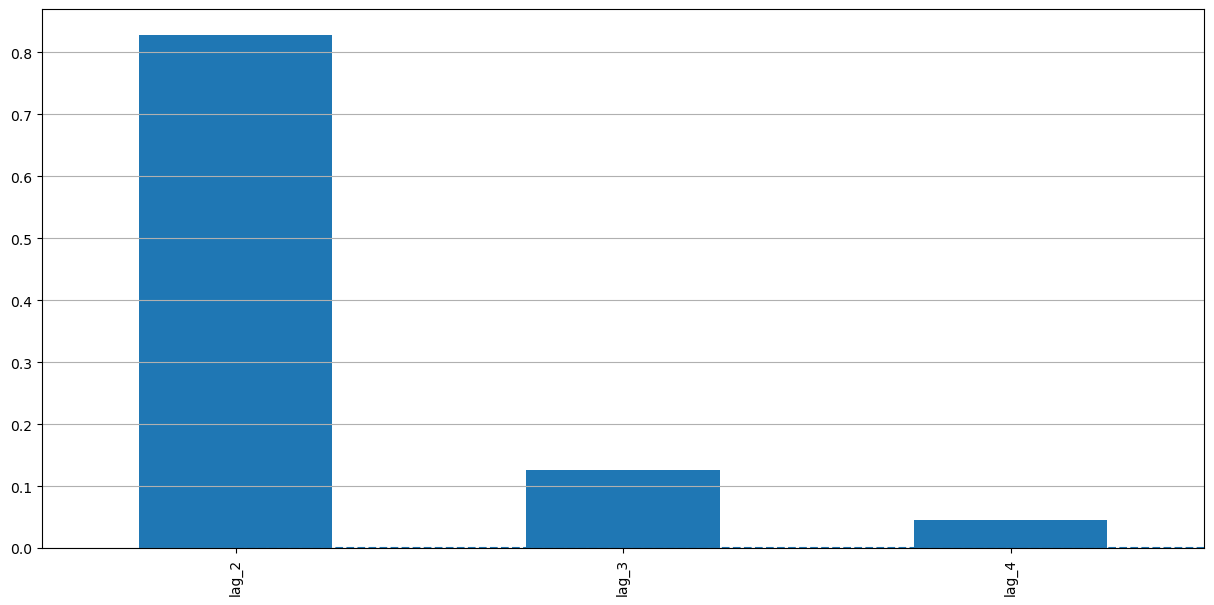



---------------------------------------
XGBoost
Forecast Bias: -19.90%
Mean Square Error: 0.0384
Mean Absolute Error: 0.1626
Mean Absolute Percentage Error: 19.90


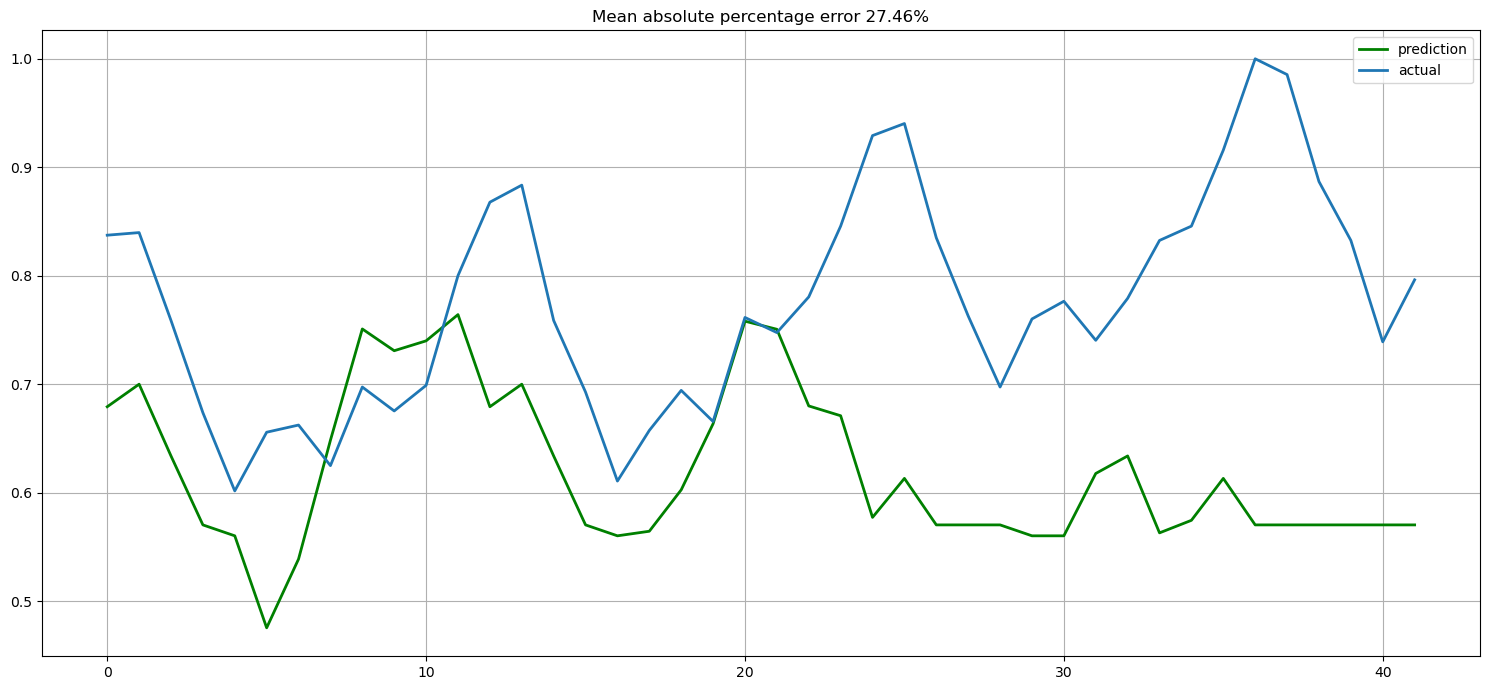

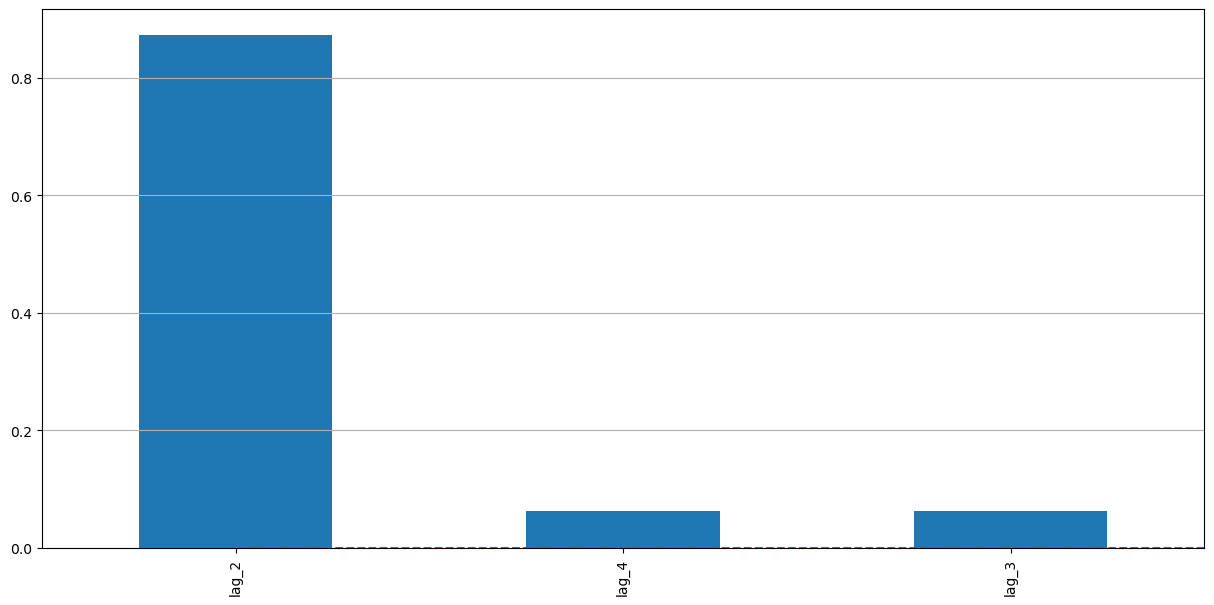

In [14]:
### Linear Regression
print("---------------------------------------")
print("Linear Regression results")
model = LinearRegression()
model = model.fit(X=X_train,
                  y=y_train)
plotModelResults(model=model,
                 X_train=X_train,
                 X_test=X_test,
                 y_test=y_test)

plotCoefficients(model=model, X_train=X_train)

### Random Forest
print("\n\n---------------------------------------")
print(f"Random Forest results")
model = RandomForestRegressor(n_estimators=50,
                              max_depth=50,
                              min_samples_leaf=3,)

model.fit(X_train, y_train)
plotModelResults(model=model,
                 X_train=X_train,
                 X_test=X_test,
                 y_test=y_test)

plotCoefficients(model=model,
                 X_train=X_train)

### XGBoost
print("\n\n---------------------------------------")
print("XGBoost")
xgb = XGBRegressor()
xgb.fit(X_train, y_train)
plotModelResults(model=xgb,
                 X_train=X_train,
                 X_test=X_test,
                 y_test=y_test)
plotCoefficients(model=xgb,
                 X_train=X_train)

### Configuración apropiada de Lag y Horizonte

En esta sección vamos a configurar los parámetros de Lag y Horizonte correctamente con el objetivo de mejorar las predicciones obtenidas.

Recordando las conclusiones extraídas con la aplicación de la autocorrelación parcial, las observaciones presentan una correlación importante con lags de 12. Por tanto, el horizonte lo podemos configurar a 10 (vamos a tratar de pronosticar el valor del número de pasajeros 10 meses del momento actual) y la observación pasada límite será la observación 14. Por tanto, emplearemos 4 observaciones para obtener el pronóstico a 10 meses vista.

#### Preparación de los datos

Repetimos el proceso de creación del time-delay embedding con la configuración descrita anteriormente

In [15]:
horizon=10
final_lag=14

data = create_time_delay_embedding(df,
                                   horizon=horizon,
                                   final_lag=final_lag,
                                   column="Min-Max-NumeroPasajeros",
                                   column_index="Month")

y = data.dropna().y
X = data.dropna().drop(['y'], axis=1)

X_train, X_test, y_train, y_test = timeseries_train_test_split(X, y, test_size=0.3)

In [16]:
aux_y_test = y_test

#### Forecasting

Una vez preparados los datos, podemos repetir el proceso de entrenamiento y evaluación. Observando los gráficos resultantes de la siguiente celda podemos apreciar que los resultados obtenidos por la regresión lineal han mejorados considerablemente. Todas las métricas de error se han reducido y es un modelo perfectamente ajustado para este conjunto de datos.

Además, estos modelos de ML permiten observar cuáles son los componentes de los datos de entrada más relevantes para obtener el pronóstico. En nuestro caso los componentes hacen referencia a las observaciones pasadas. Podemos observar en las gráficas que la componente más relevante es la correspondiente al lag 12. Esto no debería sorprendernos ya que la estacionalidad es anual y la autocorrelación parcial nos indicaba este hecho.

Sin embargo, prestando atención a los resultados obtenidos con los modelos Random Forest y XGBoost podemos apreciar que los resultados no son tan satisfactorios. Las predicciones obtenidas no se acercan a los valores reales, especialmente cuando se tienen máximos en la serie temporal original. Este hecho se debe a la tendencia que presentan los datos.

Durante la etapa de preprocesamiento nos enfocamos en la distribución de los datos y en la magnitud de los valores, pero no prestamos atención a la tendencia. Los valores basados en árboles son sensibles a tendencias pronunciadas en los datos y este es el motivo del pobre rendimiento observado con estos modelos. 

Con el objetivo de mejorar las prestaciones de estos modelos, en la siguiente sección añadiremos otra técnica ya conocida en la etapa de preprocesado.

---------------------------------------
Linear Regression results
Forecast Bias: 2.10%
Mean Square Error: 0.0010
Mean Absolute Error: 0.0248
Mean Absolute Percentage Error: 3.43


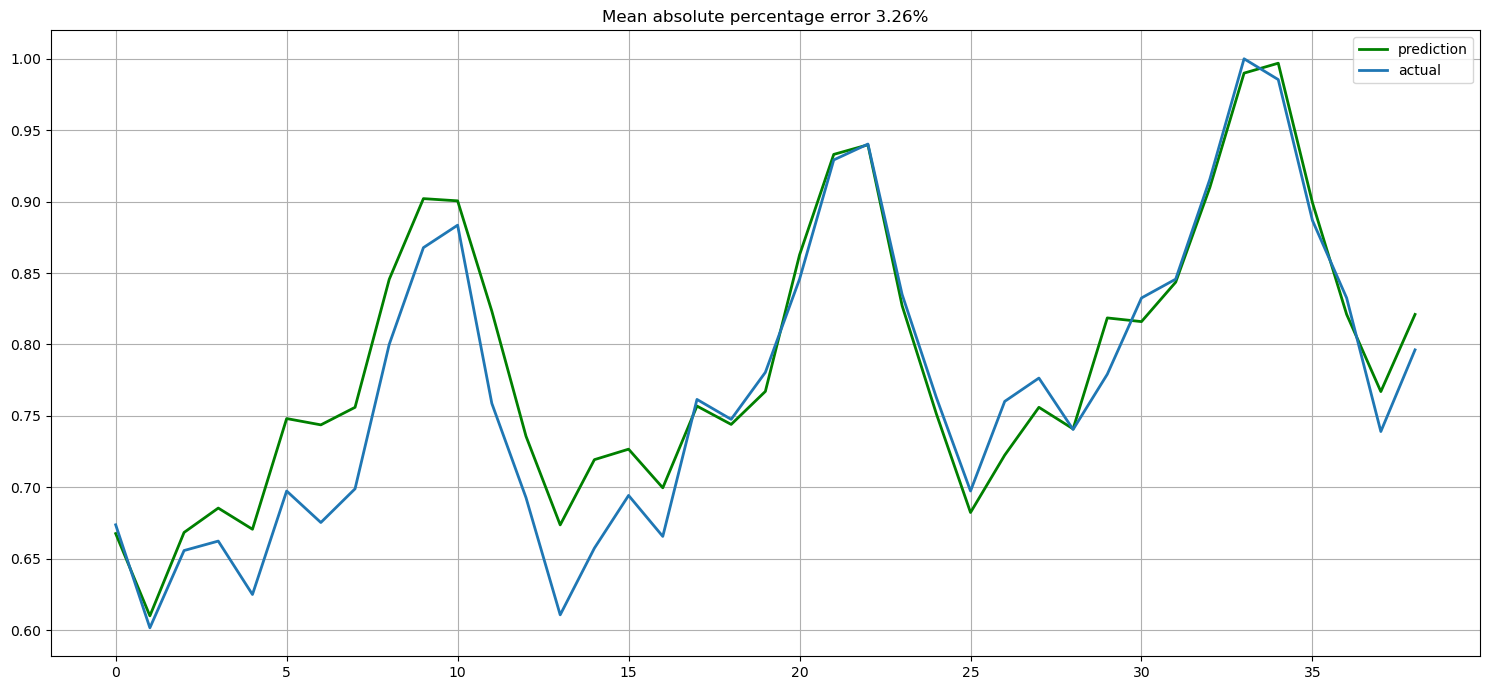

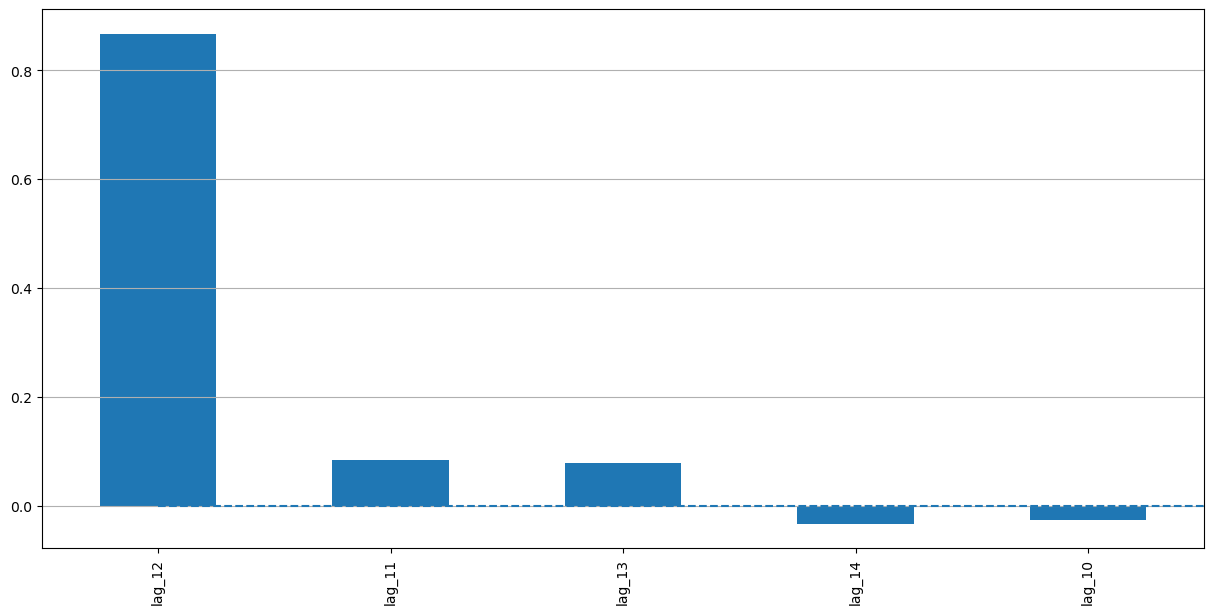



---------------------------------------
Random Forest results
Forecast Bias: -1.67%
Mean Square Error: 0.0067
Mean Absolute Error: 0.0619
Mean Absolute Percentage Error: 7.71


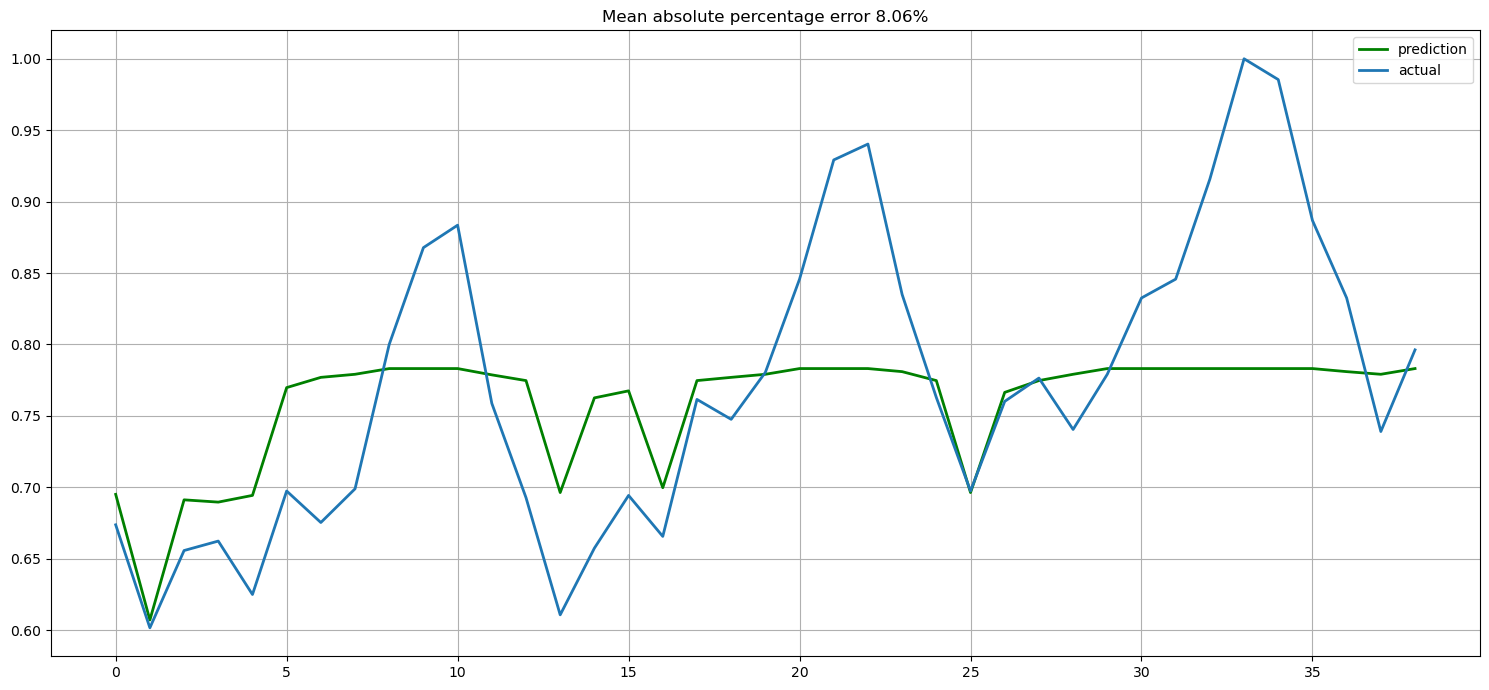

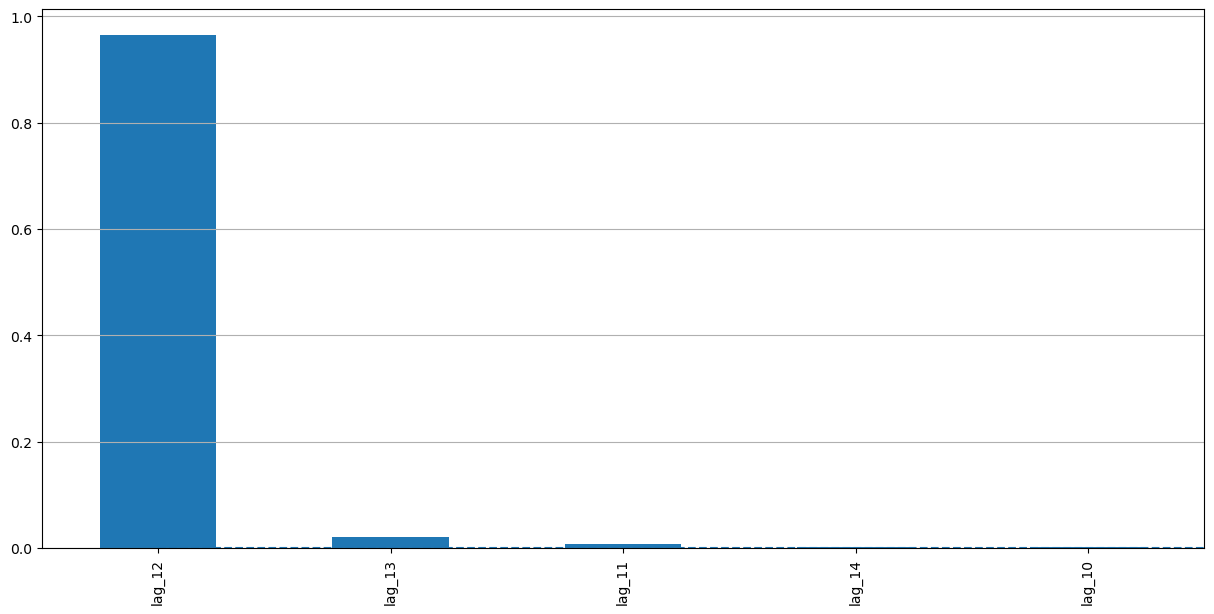



---------------------------------------
XGBoost
Forecast Bias: -1.36%
Mean Square Error: 0.0035
Mean Absolute Error: 0.0454
Mean Absolute Percentage Error: 5.70


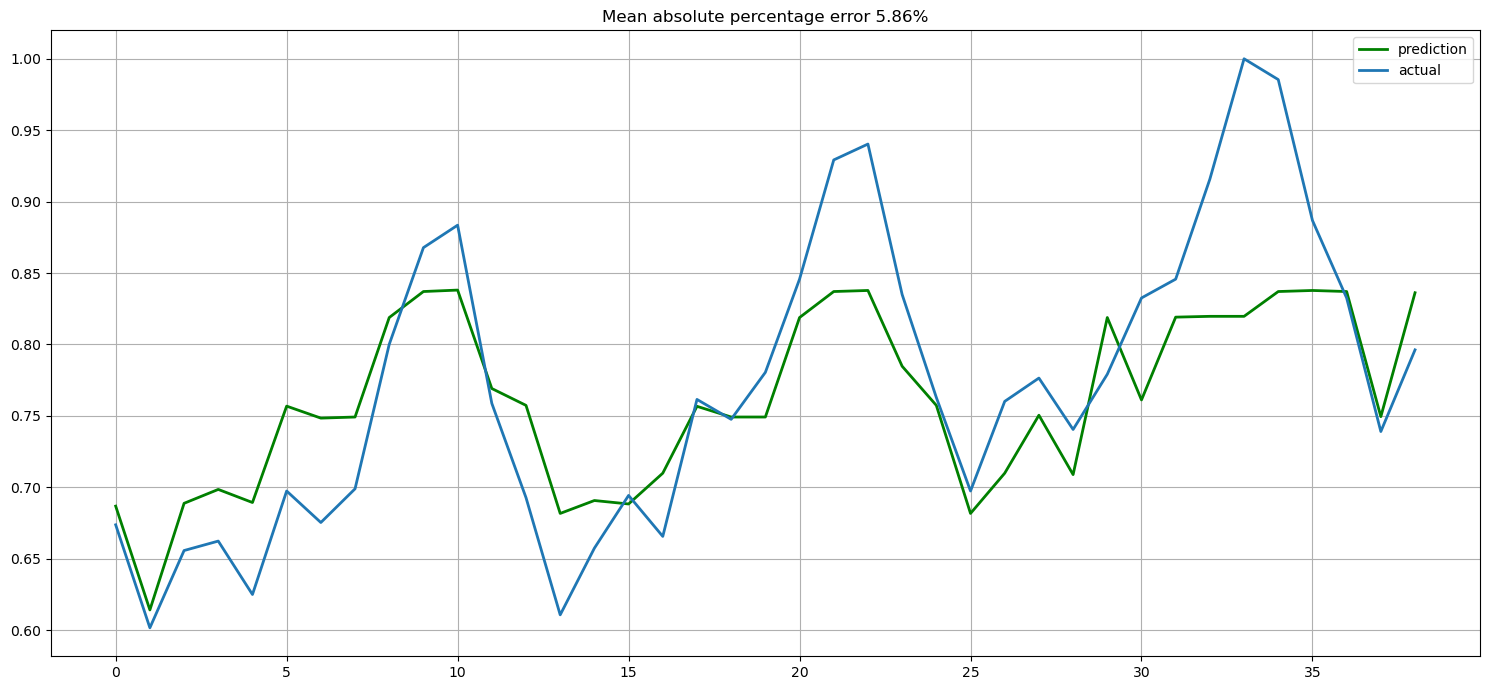

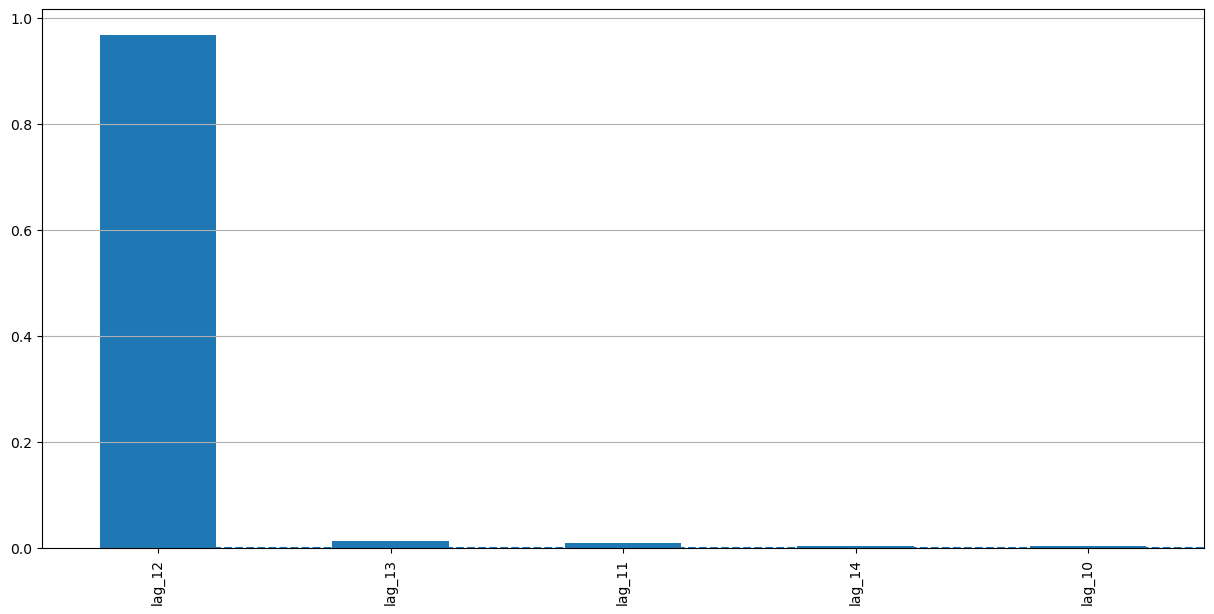

In [17]:
### Linear Regression
print("---------------------------------------")
print("Linear Regression results")
model = LinearRegression()
model = model.fit(X=X_train,
                  y=y_train)
plotModelResults(model=model,
                 X_train=X_train,
                 X_test=X_test,
                 y_test=y_test)

plotCoefficients(model=model, X_train=X_train)

### Random Forest
print("\n\n---------------------------------------")
print(f"Random Forest results")
model = RandomForestRegressor(n_estimators=50,
                              max_depth=50,
                              min_samples_leaf=3,)

model.fit(X_train, y_train)
plotModelResults(model=model,
                 X_train=X_train,
                 X_test=X_test,
                 y_test=y_test)

plotCoefficients(model=model,
                 X_train=X_train)

### XGBoost
print("\n\n---------------------------------------")
print("XGBoost")
xgb = XGBRegressor()
xgb.fit(X_train, y_train)
plotModelResults(model=xgb,
                 X_train=X_train,
                 X_test=X_test,
                 y_test=y_test)
plotCoefficients(model=xgb,
                 X_train=X_train)

## Aplicación de técnica de diferenciación

### Preprocesado de datos

Para reducir la tendencia presente en los datos aplicaremos la técnica de diferenciación. Esta técnica ya la estudiamos cuando implementamos el modelo ARIMA para modelar series temporales y poder realizar pronósticos.

La etapa de preprocesamiento será idéntica a las secciones anteriores, sin embargo incluiremos esta etapa de diferenciación al final para eliminar la tendencia. La serie resultante se observa en la figura. Observamos que la tendencia ha desaparecido por lo que estamos en disposición de entrenar nuestros modelos esperando que las prestaciones mejoren.

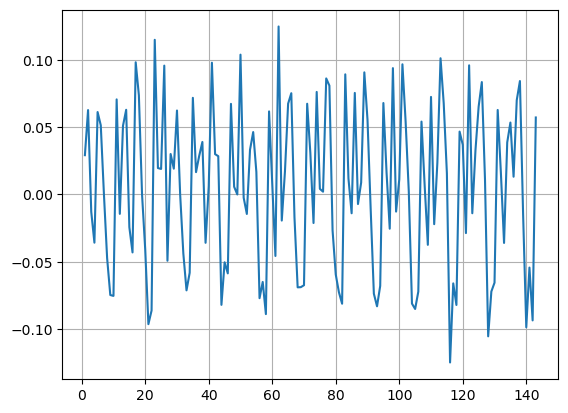

In [18]:
minmax_scaler = MinMaxScaler()
starndard_scaler = StandardScaler()

df['Fecha'] = df['Month']
df['NumerPasajeros'] = df['#Passengers']

df['LogNatural-NumeroPasajeros'] = np.log(df['NumerPasajeros'].values)

df['Min-Max-NumeroPasajeros'] = minmax_scaler.fit_transform(df['LogNatural-NumeroPasajeros'].values.reshape(-1,1))
df["diff"] = difference(df["Min-Max-NumeroPasajeros"],interval=1)

df['diff'].plot().grid()

### Preparación de datos

La fase de preparación no cambia. En este caso los datos con los que preparamos el time-delay embedding es la serie temporal diferenciada.

In [19]:
horizon=10
final_lag=14


data = create_time_delay_embedding(df,
                                   horizon=horizon,
                                   final_lag=final_lag,
                                   column="diff",
                                   column_index="Month")

y = data.dropna().y
X = data.dropna().drop(['y'], axis=1)

X_train, X_test, y_train, y_test = timeseries_train_test_split(X, y, test_size=0.3)

### Forecasting

La celda siguiente muestra los resultados obtenidos después de realizar el ajuste. Observando las gráficas vemos que los 3 modelos realizan pronósticos que se acercan a los valores reales. Sin embargo, las predicciones se realizan sobre la serie diferenciada por lo que apreciar la calidad de las predicciones de forma visual es complicado. 

Por este motivo, la siguiente celda aplica la inversa de la técnica de diferenciación para poder observar las predicciones sin aplicar la diferenciación.

---------------------------------------
Linear Regression results
Forecast Bias: 384.44%
Mean Square Error: 0.0005
Mean Absolute Error: 0.0179
Mean Absolute Percentage Error: 50.75


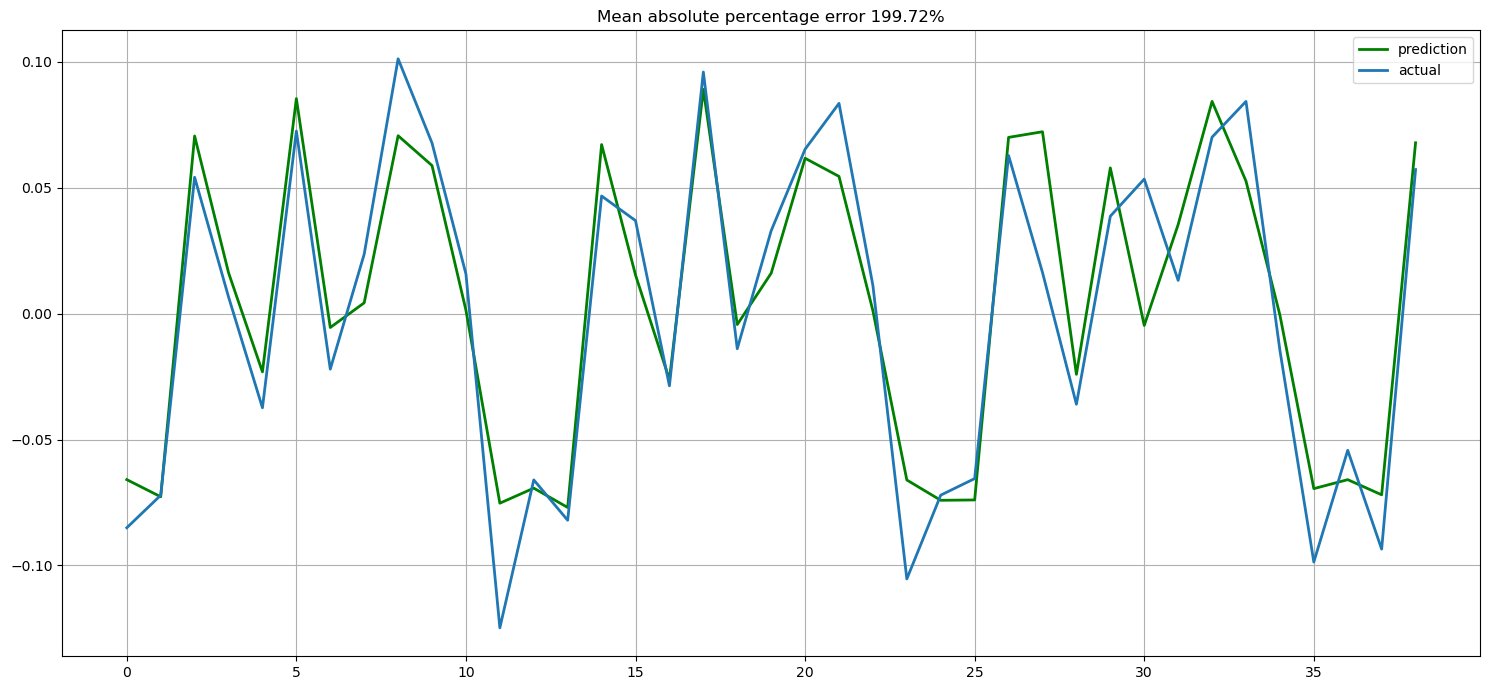

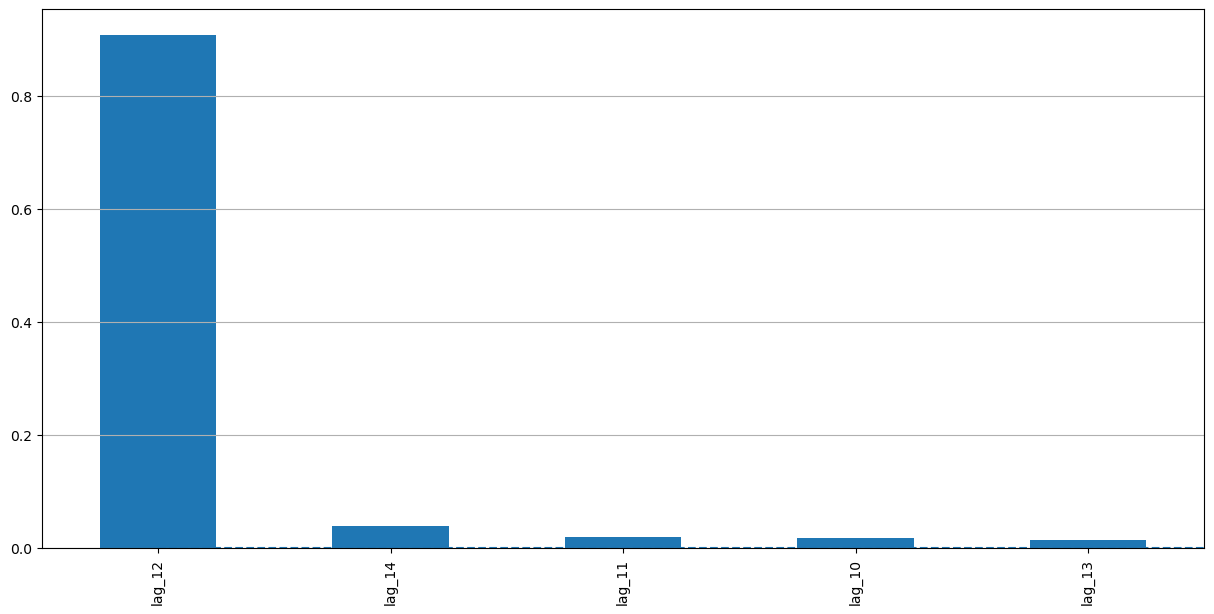



---------------------------------------
Random Forest results
Forecast Bias: 339.61%
Mean Square Error: 0.0005
Mean Absolute Error: 0.0172
Mean Absolute Percentage Error: 47.04


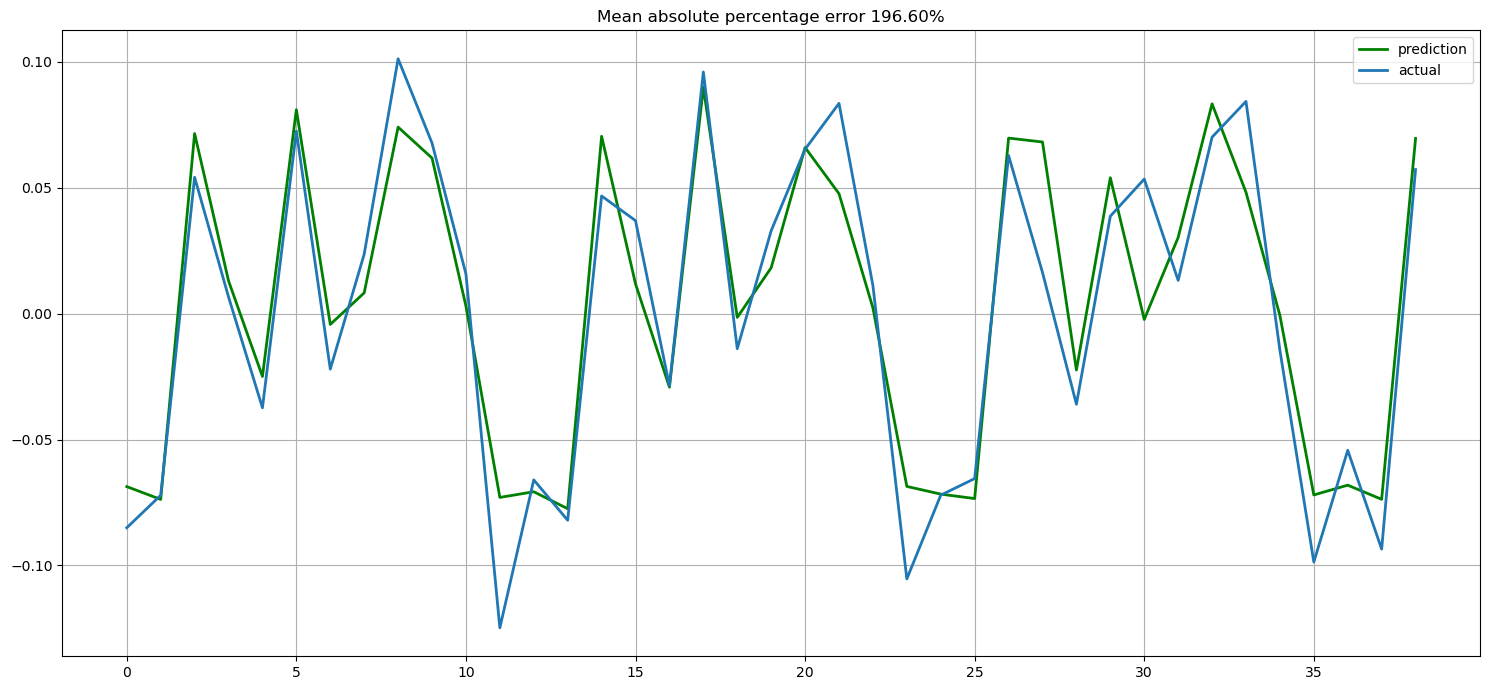

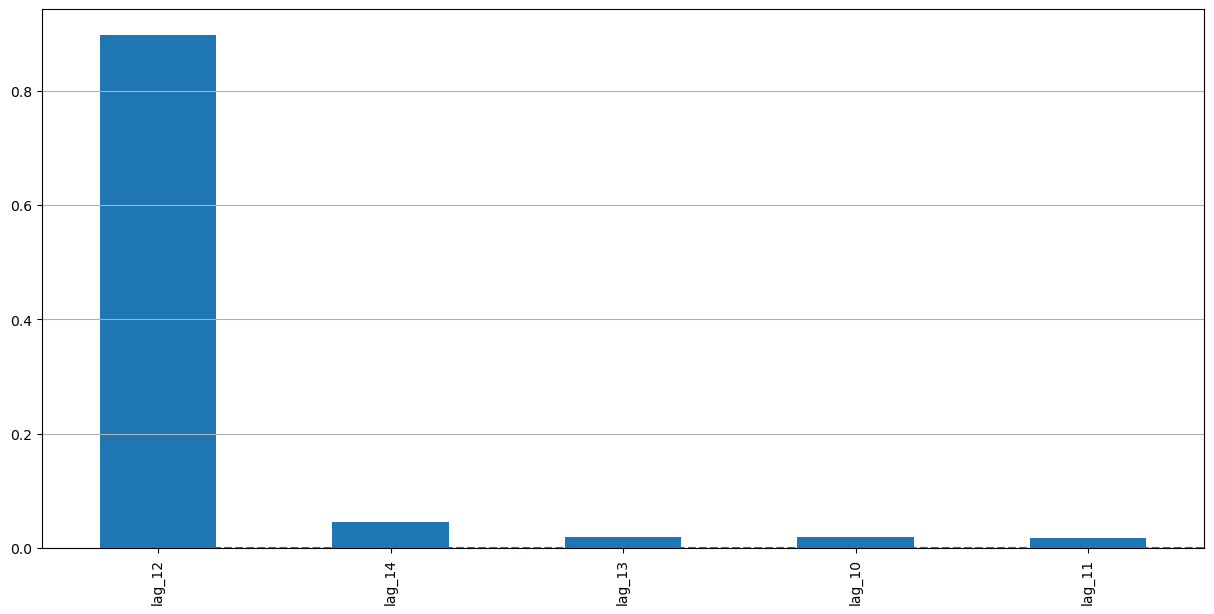



---------------------------------------
XGBoost
Forecast Bias: 7.19%
Mean Square Error: 0.0005
Mean Absolute Error: 0.0185
Mean Absolute Percentage Error: 42.35


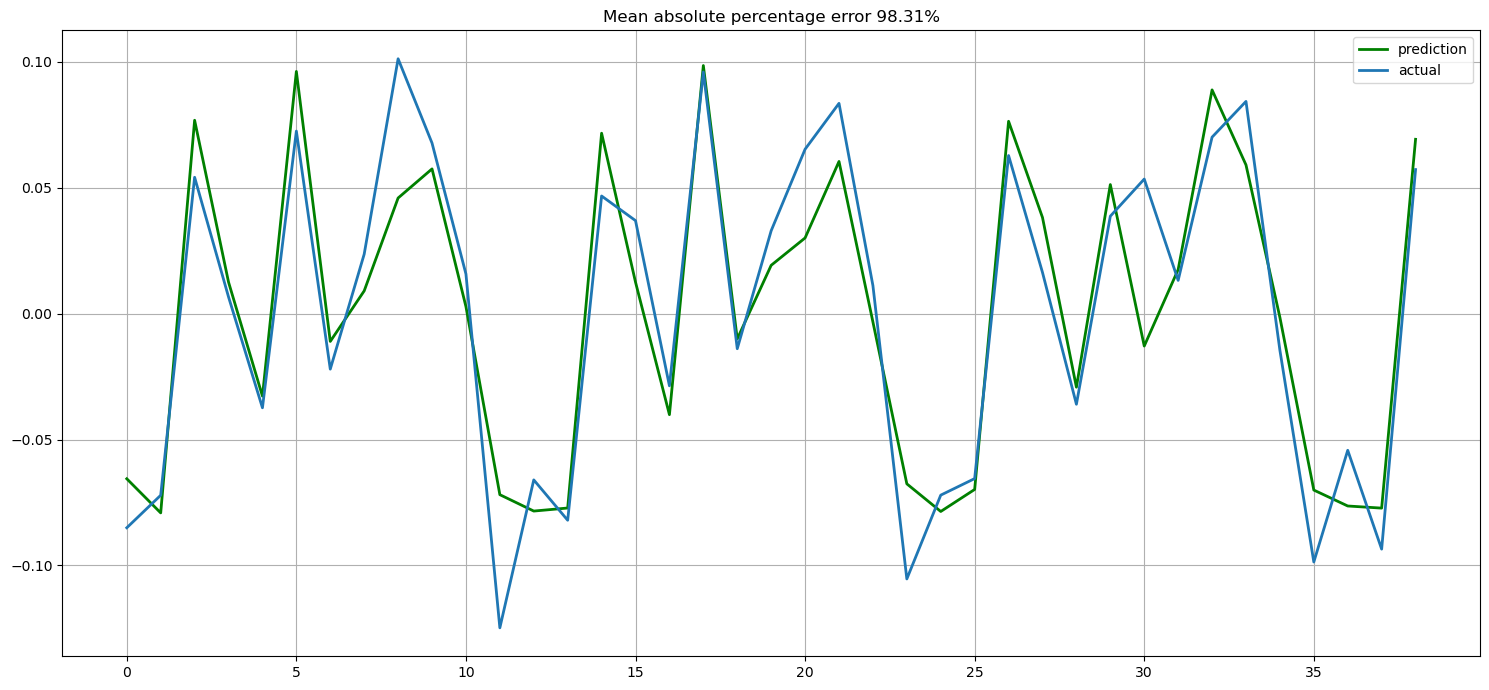

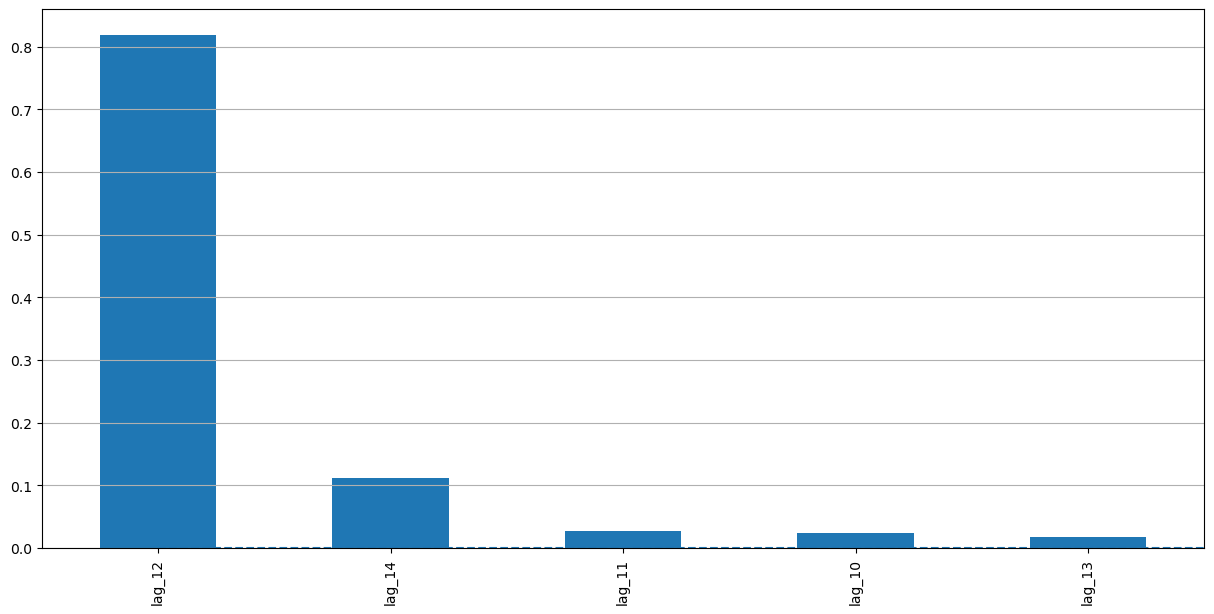

In [20]:
### Linear Regression
print("---------------------------------------")
print("Linear Regression results")
lr_model = LinearRegression()
lr_model = model.fit(X=X_train,
                     y=y_train)
plotModelResults(model=lr_model,
                 X_train=X_train,
                 X_test=X_test,
                 y_test=y_test)

plotCoefficients(model=lr_model, X_train=X_train)

### Random Forest
print("\n\n---------------------------------------")
print(f"Random Forest results")
rf_model = RandomForestRegressor(n_estimators=50,
                              max_depth=50,
                              min_samples_leaf=3,)

rf_model.fit(X_train, y_train)
plotModelResults(model=rf_model,
                 X_train=X_train,
                 X_test=X_test,
                 y_test=y_test)

plotCoefficients(model=rf_model,
                 X_train=X_train)


### XGBoost
print("\n\n---------------------------------------")
print("XGBoost")
xgb = XGBRegressor()
xgb.fit(X_train, y_train)
plotModelResults(model=xgb,
                 X_train=X_train,
                 X_test=X_test,
                 y_test=y_test)
plotCoefficients(model=xgb,
                 X_train=X_train)

Linear Regerssion results: 
Forecast Bias: 15.94%
Mean Square Error: 0.0164
Mean Absolute Error: 0.1235
Mean Absolute Percentage Error: 16.15

-----------
Random Forest results: 
Forecast Bias: 15.99%
Mean Square Error: 0.0163
Mean Absolute Error: 0.1238
Mean Absolute Percentage Error: 16.21

-----------
XGBoost results: 
Forecast Bias: 8.49%
Mean Square Error: 0.0055
Mean Absolute Error: 0.0657
Mean Absolute Percentage Error: 9.07


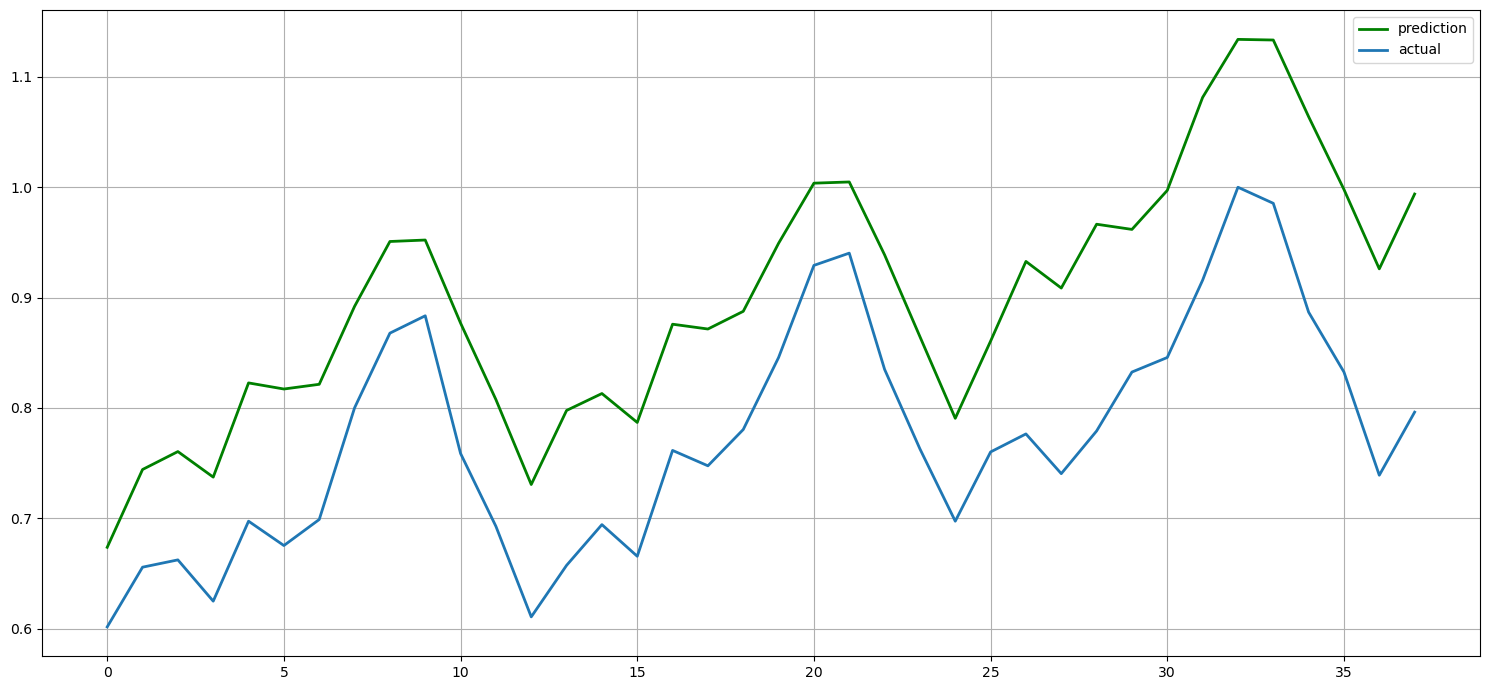

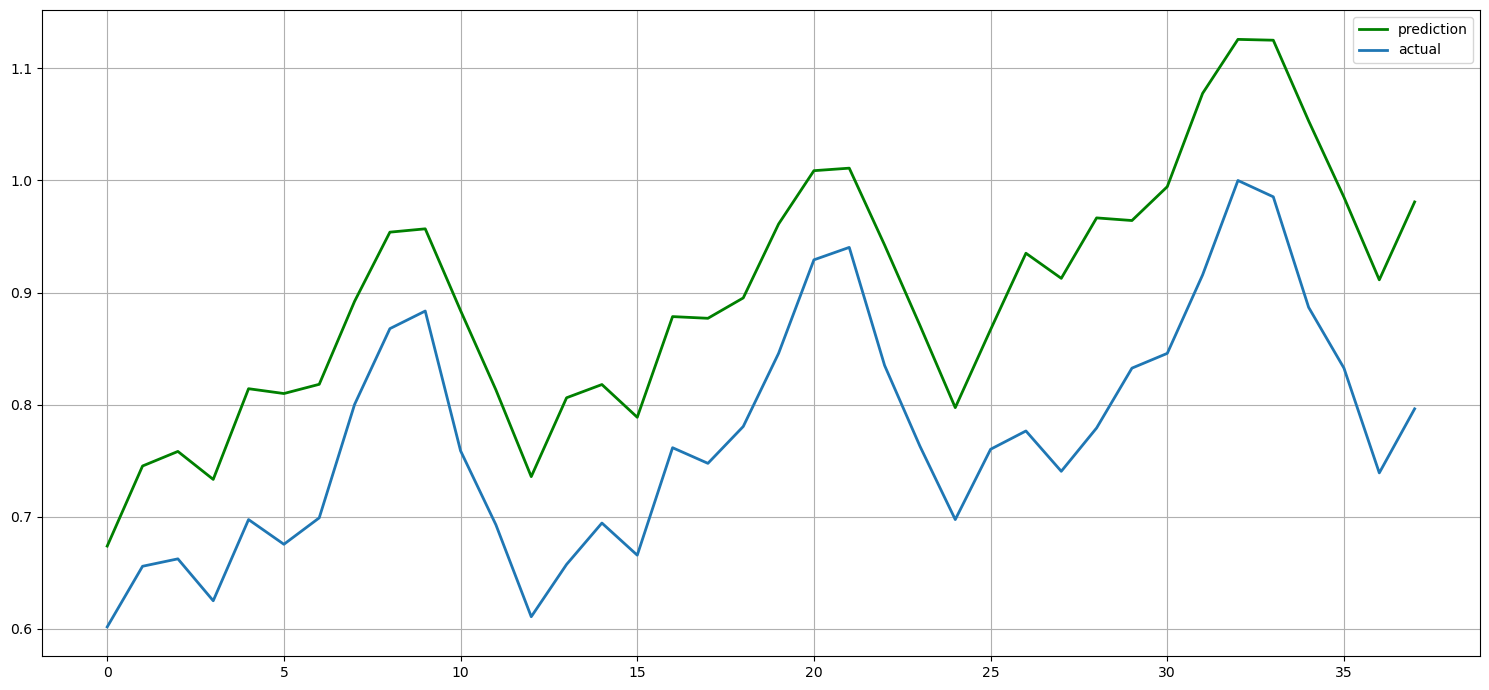

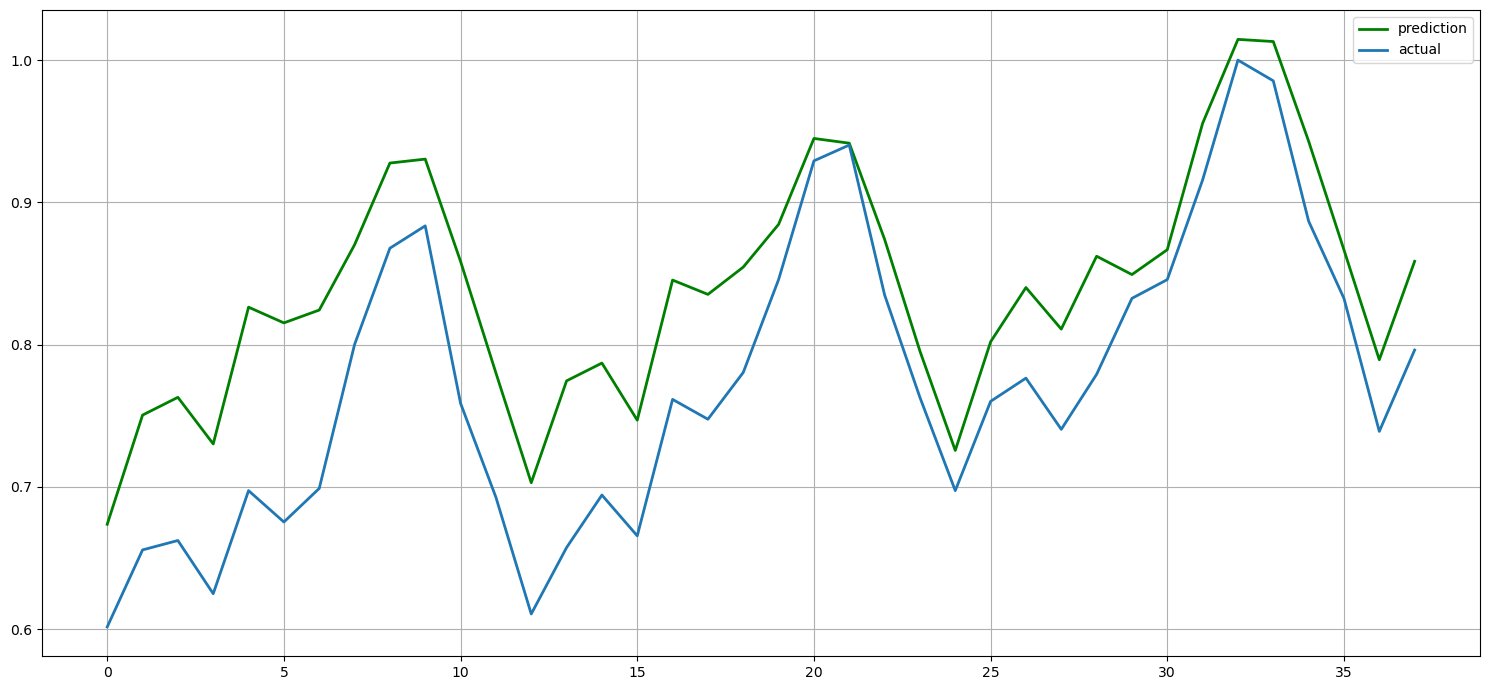

In [21]:
pred = lr_model.predict(X_test)
inverse_pred_lr = inverse_difference(diff_series=pred[1:],
                                     initial_value=df['Min-Max-NumeroPasajeros'].iloc[-X_test.shape[0]])
                                    #  initial_value=df['LogNatural-NumeroPasajeros'].iloc[-X_test.shape[0]])
print("Linear Regerssion results: ")
compute_metrics(aux_y_test[1:], inverse_pred_lr)
pred = rf_model.predict(X_test)
inverse_pred_rf = inverse_difference(diff_series=pred[1:],
                                     initial_value=df['Min-Max-NumeroPasajeros'].iloc[-X_test.shape[0]])
                                    #  initial_value=df['LogNatural-NumeroPasajeros'].iloc[-X_test.shape[0]])

print("\n-----------\nRandom Forest results: ")
compute_metrics(aux_y_test[1:], inverse_pred_rf)

pred = xgb.predict(X_test)
inverse_pred_xgb = inverse_difference(diff_series=pred[1:],
                                      initial_value=df['Min-Max-NumeroPasajeros'].iloc[-X_test.shape[0]])
                                    #   initial_value=df['LogNatural-NumeroPasajeros'].iloc[-X_test.shape[0]])

print("\n-----------\nXGBoost results: ")
compute_metrics(aux_y_test[1:], inverse_pred_xgb)

plt.figure(figsize=(15, 7))
plt.plot(inverse_pred_lr, "g", label="prediction", linewidth=2.0)
plt.plot(df['Min-Max-NumeroPasajeros'][-X_test.shape[0]+1:].values, label="actual", linewidth=2.0)
plt.legend(loc="best")
plt.tight_layout()
plt.grid(True)
plt.show()


plt.figure(figsize=(15, 7))
plt.plot(inverse_pred_rf, "g", label="prediction", linewidth=2.0)
plt.plot(df['Min-Max-NumeroPasajeros'][-X_test.shape[0]+1:].values, label="actual", linewidth=2.0)
plt.legend(loc="best")
plt.tight_layout()
plt.grid(True)
plt.show()


plt.figure(figsize=(15, 7))
plt.plot(inverse_pred_xgb, "g",
         label="prediction",
         linewidth=2.0)
plt.plot(df['Min-Max-NumeroPasajeros'][-X_test.shape[0]+1:].values,
         label="actual", linewidth=2.0)
plt.legend(loc="best")
plt.tight_layout()
plt.grid(True)
plt.show()

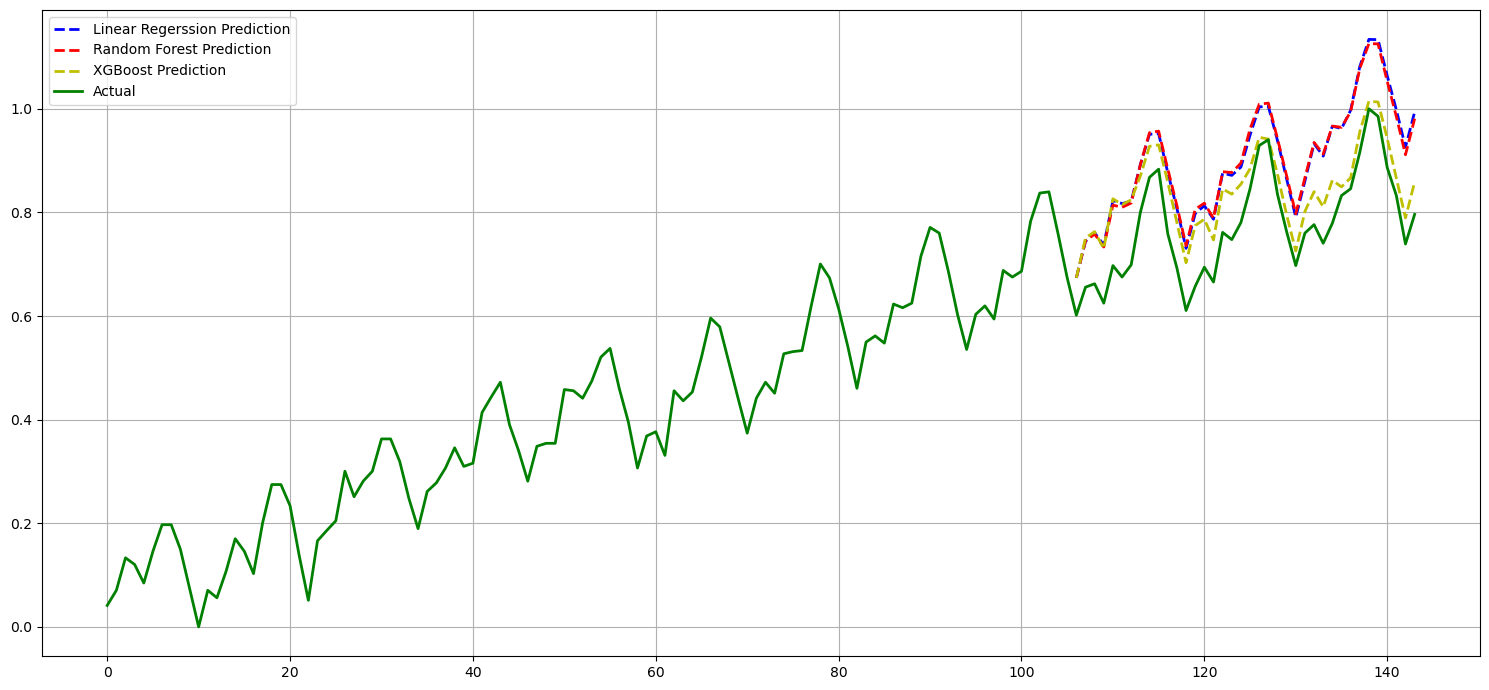

In [22]:
pred = lr_model.predict(X_test)
inverse_pred_lr = inverse_difference(diff_series=pred[1:],
                                     initial_value=df['Min-Max-NumeroPasajeros'].iloc[-X_test.shape[0]])
                                    #  initial_value=df['LogNatural-NumeroPasajeros'].iloc[-X_test.shape[0]])


pred = rf_model.predict(X_test)
inverse_pred_rf = inverse_difference(diff_series=pred[1:],
                                     initial_value=df['Min-Max-NumeroPasajeros'].iloc[-X_test.shape[0]])
                                    #  initial_value=df['LogNatural-NumeroPasajeros'].iloc[-X_test.shape[0]])

pred = xgb.predict(X_test)
inverse_pred_xgb = inverse_difference(diff_series=pred[1:],
                                     initial_value=df['Min-Max-NumeroPasajeros'].iloc[-X_test.shape[0]])
                                    #  initial_value=df['LogNatural-NumeroPasajeros'].iloc[-X_test.shape[0]])


representation_ts = []
for i in range(X_train.shape[0]):
    # representation_ts.append(df['LogNatural-NumeroPasajeros'].iloc[i])
    representation_ts.append(df['Min-Max-NumeroPasajeros'].iloc[i])

for i in range(horizon+len(inverse_pred_lr)):
    representation_ts.append(None)

representation_pred_lr = []
representation_pred_rf = []
representation_pred_xgb = []

for i in range(X_train.shape[0]):
    representation_pred_lr.append(None)
    representation_pred_rf.append(None)
    representation_pred_xgb.append(None)

for i in range(final_lag+2):
    representation_pred_lr.append(None)
    representation_pred_rf.append(None)
    representation_pred_xgb.append(None)

representation_pred_lr.extend(inverse_pred_lr)
representation_pred_rf.extend(inverse_pred_rf)
representation_pred_xgb.extend(inverse_pred_xgb)

plt.figure(figsize=(15, 7))
plt.plot(representation_pred_lr, "b--", label="Linear Regerssion Prediction", linewidth=2.0)
plt.plot(representation_pred_rf, "r--", label="Random Forest Prediction", linewidth=2.0)
plt.plot(representation_pred_xgb, "y--", label="XGBoost Prediction", linewidth=2.0)
# plt.plot(representation_ts, "g", label="Actual", linewidth=2.0)
plt.plot(df['Min-Max-NumeroPasajeros'], "g", label="Actual", linewidth=2.0)
plt.legend(loc="best")
plt.tight_layout()
plt.grid(True)
plt.show()

# ADS

In [23]:
csv_path = 'ads.csv'
df = pd.read_csv(csv_path,
                  index_col=['Time'],
                  parse_dates=['Time'])
df.head()

,Ads
Time,
2017-09-13 00:00:00,80115
2017-09-13 01:00:00,79885
2017-09-13 02:00:00,89325
2017-09-13 03:00:00,101930
2017-09-13 04:00:00,121630


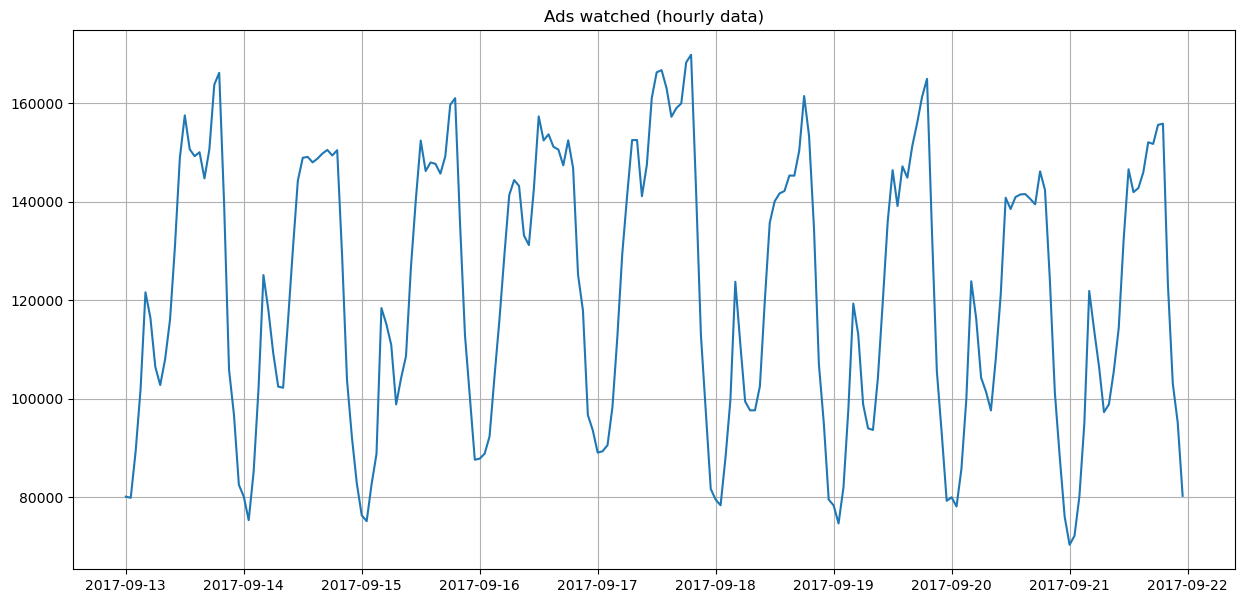

In [24]:
plt.figure(figsize=(15, 7))
plt.plot(df.Ads)
plt.title('Ads watched (hourly data)')
plt.grid(True)
plt.show()

In [25]:
df['Min-Max-Ads'] = minmax_scaler.fit_transform(df['Ads'].values.reshape(-1,1))

In [26]:
acorr = sm.tsa.acf(df['Min-Max-Ads'], nlags = 80)

fig = make_subplots(rows=1, cols=1,
                    shared_xaxes=False,
                    shared_yaxes=True,
                    vertical_spacing=0.08,
                    )

fig.add_trace(go.Scatter(y=acorr, name="Autocorrelación", mode="markers+lines"),
              row=1, col=1)

fig.add_hline(y=0.5, row=1, col=1, line_dash="dash")
fig.add_hline(y=-0.5, row=1, col=1, line_dash="dash")

fig.update_layout(height=500, width=500,
                  title_text="Autocorrelación Parcial"
                  )

fig['layout']['xaxis1']['title']='Retardo (Intervalos)'
fig.show()

In [27]:
pacorr = sm.tsa.pacf(df['Min-Max-Ads'], nlags=30)

fig = make_subplots(rows=1, cols=1,
                    shared_xaxes=False,
                    shared_yaxes=True,
                    vertical_spacing=0.08,
                    )

fig.add_trace(go.Scatter(y=pacorr, name="Autocorrelación", mode="markers+lines"),
              row=1, col=1)

fig.add_hline(y=0.5, row=1, col=1, line_dash="dash")
fig.add_hline(y=-0.5, row=1, col=1, line_dash="dash")

fig.update_layout(height=500, width=500,
                  title_text="Autocorrelación Parcial"
                  )

fig['layout']['xaxis1']['title']='Retardo (Intervalos)'
fig.show()

In [28]:
horizon=18
final_lag=24


data = create_time_delay_embedding(df,
                                   horizon=horizon,
                                   final_lag=final_lag,
                                   column="Min-Max-Ads",
                                   column_index=None)

y = data.dropna().y
X = data.dropna().drop(['y'], axis=1)

X_train, X_test, y_train, y_test = timeseries_train_test_split(X, y, test_size=0.3)

In [29]:
### Linear Regression
print("---------------------------------------")
print("Linear Regression results")
model = LinearRegression()
model = model.fit(X_train,
                  y_train=y_train)
plotModelResults(model=model,
                 X_train=X_train,
                 X_test=X_test,
                 y_test=y_test)

plotCoefficients(model=model, X_train=X_train)

### Random Forest
print("\n\n---------------------------------------")
print(f"Random Forest results")
model = RandomForestRegressor(n_estimators=50,
                              max_depth=50,
                              min_samples_leaf=3,)

model.fit(X_train, y_train)
plotModelResults(model=model,
                 X_train=X_train,
                 X_test=X_test,
                 y_test=y_test)

plotCoefficients(model=model,
                 X_train=X_train)

### XGBoost
print("\n\n---------------------------------------")
print("XGBoost")
xgb = XGBRegressor()
xgb.fit(X_train, y_train)
plotModelResults(model=xgb,
                 X_train=X_train,
                 X_test=X_test,
                 y_test=y_test)
plotCoefficients(model=xgb,
                 X_train=X_train)

---------------------------------------
Linear Regression results


TypeError: LinearRegression.fit() got an unexpected keyword argument 'y_train'

El objetivo era intentar adivinar cuántos pasajeros tendrá en los próximos meses. Se utilizaron tres modelos diferentes: regresión lineal, Random Forest y XGBoost. Después de entrenar los modelos, se realizó una comparación para ver cuál era más preciso, utilizando medidas como el error medio y el error porcentual. Al final, el modelo XGBoost dio los mejores resultados